# 📉 DoNext 5G — NB4_DSO2 : Prédiction RSRP Drop

**Pipeline :** NB1 ✅ → NB2 ✅ → NB3 ✅ → DSO1 ✅ → **NB4_DSO2**

Label : `rsrp_drop=1` si RSRP chute > 6 dBm dans les 5 prochaines mesures (Event A2/A3 3GPP)

| # | Modèle | Type |
|---|--------|------|
| M1 | XGBoost | Classique |
| M2 | LightGBM | Classique |
| M3 | Random Forest | Classique |
| M4 | BiLSTM | Deep Learning |
| M5 | TabNet (pré-entraîné) | Pré-entraîné |

---
## Section 0 — Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import json, os, gc, pickle, warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.pretraining import TabNetPretrainer
import torch

plt.rcParams.update({'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D27','axes.edgecolor':'#3A3D4D',
    'axes.labelcolor':'#E0E0E0','axes.titlecolor':'#FFFFFF','xtick.color':'#B0B0B0',
    'ytick.color':'#B0B0B0','text.color':'#E0E0E0','grid.color':'#2A2D3A',
    'grid.linestyle':'--','grid.alpha':0.5,'font.family':'monospace','figure.dpi':130})
BLUE='#4FC3F7'; GREEN='#69F0AE'; ORANGE='#FFB74D'; RED='#EF5350'; PURPLE='#CE93D8'
CM_LABELS = ['No Drop', 'Drop']

DATASET_ROOT  = r'C:\Users\THINKPAD\Desktop\DATASET'  # ← adapter
PT_OUT_DIR    = os.path.join(DATASET_ROOT, 'PT_output')
FE_OUT_DIR    = os.path.join(DATASET_ROOT, 'FE_output')
MODEL_OUT_DIR = os.path.join(DATASET_ROOT, 'MODEL_output', 'DSO2')
os.makedirs(MODEL_OUT_DIR, exist_ok=True)
print('✅ Setup OK')

✅ Setup OK


---
## Section 1 — Construction du Label RSRP Drop

In [2]:
SEUIL_DBM = -6.0; HORIZON = 5
CONFIGS = {'static':'session_id','mobile':'device','hbahn':'device'}

df_fe = pd.read_parquet(os.path.join(FE_OUT_DIR,'df_final_fe.parquet'),
                         columns=['rsrp','session_id','source_folder','device'])
df = pd.read_parquet(os.path.join(PT_OUT_DIR,'df_preprocessed.parquet'))
df_fe = df_fe.reset_index(drop=True)
df_fe['rsrp_drop'] = 0

print(f'Seuil={SEUIL_DBM} dBm | Horizon={HORIZON}')
for env, cle in CONFIGS.items():
    if cle not in df_fe.columns: continue
    mask_env = df_fe['source_folder']==env
    for _, grp in df_fe[mask_env].groupby(cle):
        rsrp_v = grp['rsrp'].values; idxs = grp.index; n = len(rsrp_v)
        for i in range(n-HORIZON):
            if (rsrp_v[i+1:i+1+HORIZON].min()-rsrp_v[i]) < SEUIL_DBM:
                df_fe.at[idxs[i],'rsrp_drop']=1
    nd = df_fe.loc[mask_env,'rsrp_drop'].sum()
    print(f'  {env}: {nd:,} drops ({nd/mask_env.sum()*100:.1f}%)')

total_drop=df_fe['rsrp_drop'].sum(); total=len(df_fe)
ratio_drop=int((total-total_drop)/max(total_drop,1))
print(f'TOTAL {total_drop:,}/{total:,} ({total_drop/total*100:.2f}%) | ratio 1:{ratio_drop}')
df['rsrp_drop'] = df_fe['rsrp_drop'].values

Seuil=-6.0 dBm | Horizon=5
  static: 20,197 drops (0.2%)
  mobile: 346,458 drops (14.5%)
  hbahn: 104,042 drops (21.0%)
TOTAL 470,697/12,602,863 (3.73%) | ratio 1:25


In [3]:
idx_train=np.load(os.path.join(PT_OUT_DIR,'idx_train.npy'),allow_pickle=True)
idx_val  =np.load(os.path.join(PT_OUT_DIR,'idx_val.npy'),  allow_pickle=True)
idx_test =np.load(os.path.join(PT_OUT_DIR,'idx_test.npy'), allow_pickle=True)
with open(os.path.join(PT_OUT_DIR,'config.json')) as f: config=json.load(f)
COLS_X=[c for c in config['cols_X'] if c in df.columns and c!='rsrp_drop']
y_train=df.loc[idx_train,'rsrp_drop'].values
y_val  =df.loc[idx_val,  'rsrp_drop'].values
y_test =df.loc[idx_test, 'rsrp_drop'].values
X_train=df.loc[idx_train,COLS_X].values.astype(np.float32)
X_val  =df.loc[idx_val,  COLS_X].values.astype(np.float32)
X_test =df.loc[idx_test, COLS_X].values.astype(np.float32)
ratio=int((1-y_train.mean())/max(y_train.mean(),1e-6))
print(f'X_train {X_train.shape} | Drop%={y_train.mean()*100:.2f}% | ratio 1:{ratio}')

X_train (8822003, 104) | Drop%=3.97% | ratio 1:24


---
## Section 2 — M1 : XGBoost

In [4]:
print('='*60+'\n  M1 — XGBoost DSO2\n'+'='*60)
xgb_d2=XGBClassifier(n_estimators=500,max_depth=6,learning_rate=0.05,subsample=0.8,
    colsample_bytree=0.8,scale_pos_weight=ratio,eval_metric='aucpr',
    early_stopping_rounds=30,tree_method='hist',random_state=42,n_jobs=-1,use_label_encoder=False)
xgb_d2.fit(X_train,y_train,eval_set=[(X_val,y_val)],verbose=50)
y_pred_xgb=xgb_d2.predict(X_test); y_prob_xgb=xgb_d2.predict_proba(X_test)[:,1]
print(classification_report(y_test,y_pred_xgb,target_names=CM_LABELS))
metrics_xgb={'model':'XGBoost','f1':round(f1_score(y_test,y_pred_xgb),4),
    'precision':round(precision_score(y_test,y_pred_xgb),4),'recall':round(recall_score(y_test,y_pred_xgb),4),
    'auc_roc':round(roc_auc_score(y_test,y_prob_xgb),4),'auc_pr':round(average_precision_score(y_test,y_prob_xgb),4)}
with open(os.path.join(MODEL_OUT_DIR,'xgb_dso2.pkl'),'wb') as f: pickle.dump(xgb_d2,f)

  M1 — XGBoost DSO2
[0]	validation_0-aucpr:0.28149
[50]	validation_0-aucpr:0.47532
[100]	validation_0-aucpr:0.49392
[150]	validation_0-aucpr:0.50520
[200]	validation_0-aucpr:0.51454
[250]	validation_0-aucpr:0.51883
[300]	validation_0-aucpr:0.52193
[350]	validation_0-aucpr:0.52383
[400]	validation_0-aucpr:0.52489
[403]	validation_0-aucpr:0.52488
              precision    recall  f1-score   support

     No Drop       1.00      0.85      0.92   1824958
        Drop       0.18      0.94      0.30     65474

    accuracy                           0.85   1890432
   macro avg       0.59      0.89      0.61   1890432
weighted avg       0.97      0.85      0.89   1890432



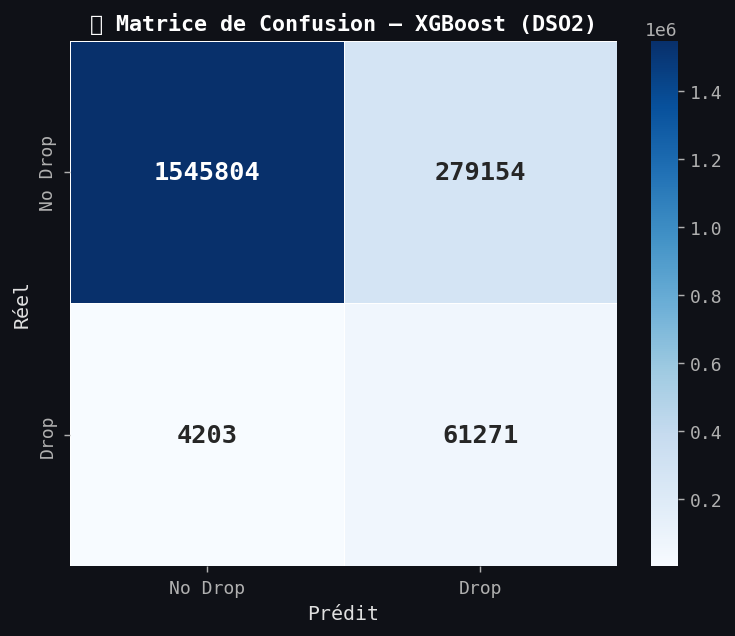

  VN=1,545,804  FP=279,154
  FN=4,203  VP=61,271


In [5]:
# ── Matrice de Confusion — XGBoost ───────────────────────────────────────────
cm_xgb=confusion_matrix(y_test,y_pred_xgb)
fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(cm_xgb,annot=True,fmt='d',cmap='Blues',xticklabels=CM_LABELS,yticklabels=CM_LABELS,
    linewidths=0.5,ax=ax,annot_kws={'size':14,'weight':'bold'})
ax.set_xlabel('Prédit',fontsize=11); ax.set_ylabel('Réel',fontsize=11)
ax.set_title('🔢 Matrice de Confusion — XGBoost (DSO2)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_xgb_dso2.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()
print(f'  VN={cm_xgb[0,0]:,}  FP={cm_xgb[0,1]:,}\n  FN={cm_xgb[1,0]:,}  VP={cm_xgb[1,1]:,}')

---
## Section 3 — M2 : LightGBM

In [6]:
print('='*60+'\n  M2 — LightGBM DSO2\n'+'='*60)
lgbm_d2=LGBMClassifier(n_estimators=500,max_depth=7,learning_rate=0.05,num_leaves=63,
    subsample=0.8,colsample_bytree=0.8,is_unbalance=True,metric='average_precision',
    random_state=42,n_jobs=-1,verbose=-1)
lgbm_d2.fit(X_train,y_train,eval_set=[(X_val,y_val)],
    callbacks=[lgb.early_stopping(30,verbose=False),lgb.log_evaluation(50)])
y_pred_lgbm=lgbm_d2.predict(X_test); y_prob_lgbm=lgbm_d2.predict_proba(X_test)[:,1]
print(classification_report(y_test,y_pred_lgbm,target_names=CM_LABELS))
metrics_lgbm={'model':'LightGBM','f1':round(f1_score(y_test,y_pred_lgbm),4),
    'precision':round(precision_score(y_test,y_pred_lgbm),4),'recall':round(recall_score(y_test,y_pred_lgbm),4),
    'auc_roc':round(roc_auc_score(y_test,y_prob_lgbm),4),'auc_pr':round(average_precision_score(y_test,y_prob_lgbm),4)}
with open(os.path.join(MODEL_OUT_DIR,'lgbm_dso2.pkl'),'wb') as f: pickle.dump(lgbm_d2,f)

  M2 — LightGBM DSO2
[50]	valid_0's average_precision: 0.477923
[100]	valid_0's average_precision: 0.507093
[150]	valid_0's average_precision: 0.516681
[200]	valid_0's average_precision: 0.522004
[250]	valid_0's average_precision: 0.526302
[300]	valid_0's average_precision: 0.529554
[350]	valid_0's average_precision: 0.531339
[400]	valid_0's average_precision: 0.533965
[450]	valid_0's average_precision: 0.475691
              precision    recall  f1-score   support

     No Drop       1.00      0.87      0.93   1824958
        Drop       0.20      0.89      0.33     65474

    accuracy                           0.87   1890432
   macro avg       0.60      0.88      0.63   1890432
weighted avg       0.97      0.87      0.91   1890432



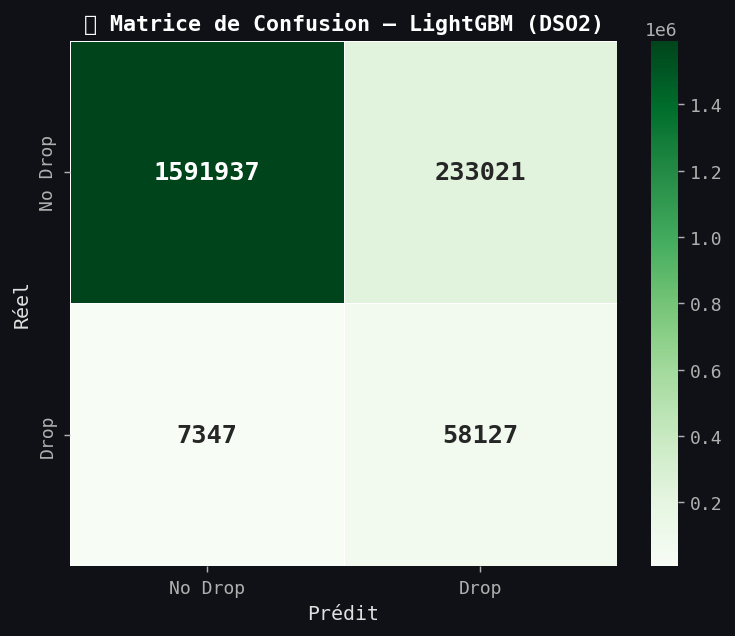

  VN=1,591,937  FP=233,021
  FN=7,347  VP=58,127


In [7]:
# ── Matrice de Confusion — LightGBM ──────────────────────────────────────────
cm_lgbm=confusion_matrix(y_test,y_pred_lgbm)
fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(cm_lgbm,annot=True,fmt='d',cmap='Greens',xticklabels=CM_LABELS,yticklabels=CM_LABELS,
    linewidths=0.5,ax=ax,annot_kws={'size':14,'weight':'bold'})
ax.set_xlabel('Prédit',fontsize=11); ax.set_ylabel('Réel',fontsize=11)
ax.set_title('🔢 Matrice de Confusion — LightGBM (DSO2)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_lgbm_dso2.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()
print(f'  VN={cm_lgbm[0,0]:,}  FP={cm_lgbm[0,1]:,}\n  FN={cm_lgbm[1,0]:,}  VP={cm_lgbm[1,1]:,}')

---
## Section 4 — M3 : Random Forest

In [8]:
print('='*60+'\n  M3 — Random Forest DSO2\n'+'='*60)
rf_d2=RandomForestClassifier(n_estimators=300,max_depth=15,min_samples_leaf=20,
    max_features='sqrt',class_weight='balanced_subsample',max_samples=0.2,
    random_state=42,n_jobs=-1,verbose=1)
rf_d2.fit(X_train,y_train)
y_pred_rf=rf_d2.predict(X_test); y_prob_rf=rf_d2.predict_proba(X_test)[:,1]
print(classification_report(y_test,y_pred_rf,target_names=CM_LABELS))
metrics_rf={'model':'Random Forest','f1':round(f1_score(y_test,y_pred_rf),4),
    'precision':round(precision_score(y_test,y_pred_rf),4),'recall':round(recall_score(y_test,y_pred_rf),4),
    'auc_roc':round(roc_auc_score(y_test,y_prob_rf),4),'auc_pr':round(average_precision_score(y_test,y_prob_rf),4)}
with open(os.path.join(MODEL_OUT_DIR,'rf_dso2.pkl'),'wb') as f: pickle.dump(rf_d2,f)

  M3 — Random Forest DSO2


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   37.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  4.6min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  7.9min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.5s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    4.6s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    8.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.5s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    4.7s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    8.2s finished


              precision    recall  f1-score   support

     No Drop       1.00      0.84      0.91   1824958
        Drop       0.18      0.94      0.30     65474

    accuracy                           0.85   1890432
   macro avg       0.59      0.89      0.61   1890432
weighted avg       0.97      0.85      0.89   1890432



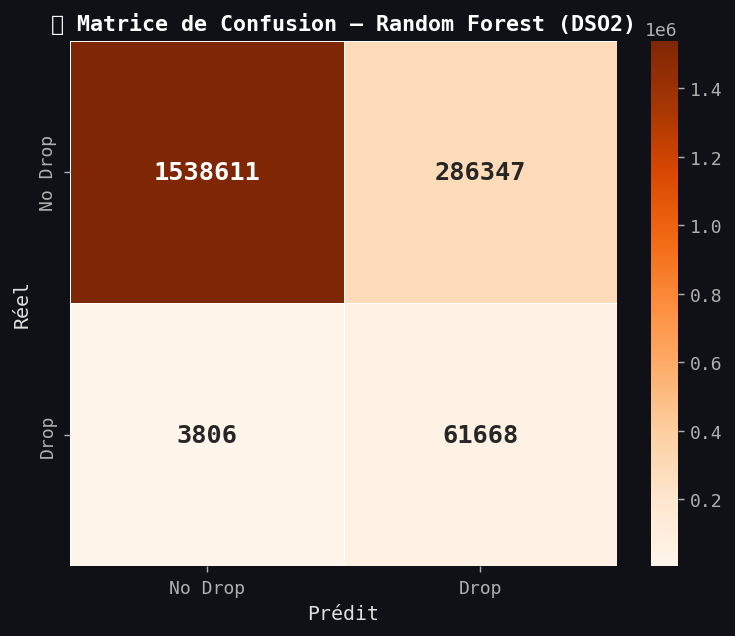

  VN=1,538,611  FP=286,347
  FN=3,806  VP=61,668


In [9]:
# ── Matrice de Confusion — Random Forest ─────────────────────────────────────
cm_rf=confusion_matrix(y_test,y_pred_rf)
fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Oranges',xticklabels=CM_LABELS,yticklabels=CM_LABELS,
    linewidths=0.5,ax=ax,annot_kws={'size':14,'weight':'bold'})
ax.set_xlabel('Prédit',fontsize=11); ax.set_ylabel('Réel',fontsize=11)
ax.set_title('🔢 Matrice de Confusion — Random Forest (DSO2)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_rf_dso2.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()
print(f'  VN={cm_rf[0,0]:,}  FP={cm_rf[0,1]:,}\n  FN={cm_rf[1,0]:,}  VP={cm_rf[1,1]:,}')

---
## Section 5 — M4 : BiLSTM (Deep Learning)

In [10]:
print('='*60+'\n  M4 — BiLSTM DSO2\n'+'='*60)
WINDOW_COLS=[c for c in COLS_X if any(f'_t-{k}' in c for k in range(1,6))]
T=5 if WINDOW_COLS else 1
if WINDOW_COLS:
    w_idx=[list(COLS_X).index(c) for c in WINDOW_COLS]; F=len(w_idx)//T
    X_tr_3d=X_train[:,w_idx].reshape(-1,T,F); X_va_3d=X_val[:,w_idx].reshape(-1,T,F); X_te_3d=X_test[:,w_idx].reshape(-1,T,F)
else:
    F=X_train.shape[1]; T=1
    X_tr_3d=X_train.reshape(-1,1,F); X_va_3d=X_val.reshape(-1,1,F); X_te_3d=X_test.reshape(-1,1,F)
tf.random.set_seed(42)
inp=Input(shape=(T,F))
x=Bidirectional(LSTM(128,return_sequences=True,dropout=0.2))(inp)
x=BatchNormalization()(x); x=Bidirectional(LSTM(64,return_sequences=False,dropout=0.2))(x)
x=BatchNormalization()(x); x=Dense(64,activation='relu')(x); x=Dropout(0.3)(x)
out=Dense(1,activation='sigmoid')(x)
lstm_d2=Model(inputs=inp,outputs=out,name='BiLSTM_DSO2')
lstm_d2.compile(optimizer=Adam(1e-3),loss='binary_crossentropy',metrics=['AUC'])
sw=np.where(y_train==1,ratio,1).astype(np.float32)
history_d2=lstm_d2.fit(X_tr_3d,y_train,validation_data=(X_va_3d,y_val),sample_weight=sw,
    epochs=30,batch_size=2048,verbose=1,
    callbacks=[EarlyStopping(monitor='val_AUC',patience=5,restore_best_weights=True,mode='max'),
               ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-6),
               ModelCheckpoint(os.path.join(MODEL_OUT_DIR,'lstm_dso2_best.h5'),monitor='val_AUC',save_best_only=True,mode='max')])
y_prob_lstm=lstm_d2.predict(X_te_3d,batch_size=4096,verbose=0).flatten()
y_pred_lstm=(y_prob_lstm>0.5).astype(int)
print(classification_report(y_test,y_pred_lstm,target_names=CM_LABELS))
metrics_lstm={'model':'BiLSTM','f1':round(f1_score(y_test,y_pred_lstm),4),
    'precision':round(precision_score(y_test,y_pred_lstm),4),'recall':round(recall_score(y_test,y_pred_lstm),4),
    'auc_roc':round(roc_auc_score(y_test,y_prob_lstm),4),'auc_pr':round(average_precision_score(y_test,y_prob_lstm),4)}
lstm_d2.save(os.path.join(MODEL_OUT_DIR,'lstm_dso2.h5'))

  M4 — BiLSTM DSO2
Epoch 1/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - AUC: 0.5164 - loss: 1.3352  

4308/4308 ━━━━━━━━━━━━━━━━━━━━ 310s 68ms/step - AUC: 0.5154 - loss: 1.3238 - val_AUC: 0.5000 - val_loss: 0.6896 - learning_rate: 0.0010
Epoch 2/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 305s 71ms/step - AUC: 0.5164 - loss: 1.3193 - val_AUC: 0.5000 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 3/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 185s 41ms/step - AUC: 0.5134 - loss: 1.3201 - val_AUC: 0.5000 - val_loss: 0.6949 - learning_rate: 0.0010
Epoch 4/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 203s 41ms/step - AUC: 0.5155 - loss: 1.3189 - val_AUC: 0.5000 - val_loss: 0.6921 - learning_rate: 0.0010
Epoch 5/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 210s 43ms/step - AUC: 0.5259 - loss: 1.3153 - val_AUC: 0.5000 - val_loss: 0.6785 - learning_rate: 5.0000e-04
Epoch 6/30
4308/4308 ━━━━━━━━━━━━━━━━━━━━ 194s 45ms/step - AUC: 0.5230 - loss: 1.3167 - val_AUC: 0.5000 - val_loss: 0.6813 - learning_rate: 5.0000e-04
              precision    recall  f1-score   support

     No Drop       0.97      1.00      0.98   1824958
        Drop

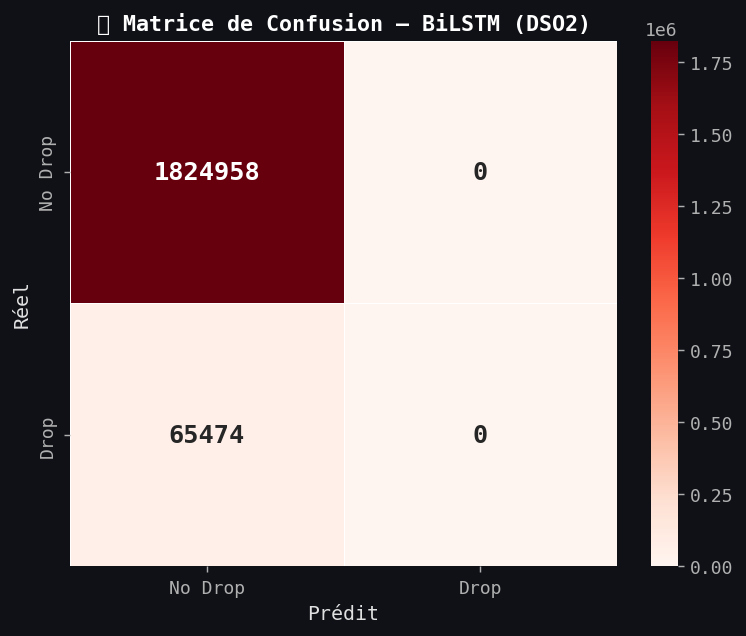

  VN=1,824,958  FP=0
  FN=65,474  VP=0


In [11]:
# ── Matrice de Confusion — BiLSTM ────────────────────────────────────────────
cm_lstm=confusion_matrix(y_test,y_pred_lstm)
fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(cm_lstm,annot=True,fmt='d',cmap='Reds',xticklabels=CM_LABELS,yticklabels=CM_LABELS,
    linewidths=0.5,ax=ax,annot_kws={'size':14,'weight':'bold'})
ax.set_xlabel('Prédit',fontsize=11); ax.set_ylabel('Réel',fontsize=11)
ax.set_title('🔢 Matrice de Confusion — BiLSTM (DSO2)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_lstm_dso2.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()
print(f'  VN={cm_lstm[0,0]:,}  FP={cm_lstm[0,1]:,}\n  FN={cm_lstm[1,0]:,}  VP={cm_lstm[1,1]:,}')

---
## Section 6 — M5 : TabNet (Pré-entraîné)

In [14]:
print('='*60+'\n  M5 — TabNet DSO2\n'+'='*60)

# ── 1. float32 + sampling ────────────────────────────────────
N_TN = min(100_000, len(X_train))
idx_tn = np.random.choice(len(X_train), N_TN, replace=False)
X_tr_tn    = X_train[idx_tn].astype(np.float32)   # ✅ float32
X_va_tn    = X_val.astype(np.float32)
X_te_tn    = X_test.astype(np.float32)
y_train_tn = y_train[idx_tn]
print(f'Sample train : {len(X_tr_tn)}')

# ── 2. Pretraining (sans concat train+val) ───────────────────
pt_d2 = TabNetPretrainer(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2, mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=5, seed=42
)
pt_d2.fit(
    X_train=X_tr_tn,          # ✅ pas de concat
    eval_set=[X_va_tn],
    max_epochs=30, patience=5,
    batch_size=2048, virtual_batch_size=256,
    pretraining_ratio=0.5
)

# ── 3. Modèle supervisé ─────────────────────────────────────
tabnet_d2 = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2, mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=0, seed=42
)

# ✅ Mini-fit pour initialiser le réseau avant load_weights
tabnet_d2.fit(
    X_train=X_tr_tn[:512],
    y_train=y_train_tn[:512].astype(int),
    max_epochs=1, batch_size=512, virtual_batch_size=512
)

# ✅ Transfert des poids encodeur
tabnet_d2.load_weights_from_unsupervised(pt_d2)

# ── 4. Entraînement réel ─────────────────────────────────────
tabnet_d2.verbose = 10
tabnet_d2.fit(
    X_train=X_tr_tn,
    y_train=y_train_tn.astype(int),
    eval_set=[(X_va_tn, y_val.astype(int))],
    eval_metric=['auc'],
    max_epochs=30, patience=5,
    batch_size=2048, virtual_batch_size=256,
    weights=1
)

# ── 5. Évaluation ────────────────────────────────────────────
y_pred_tn = tabnet_d2.predict(X_te_tn)
y_prob_tn = tabnet_d2.predict_proba(X_te_tn)[:, 1]
print(classification_report(y_test, y_pred_tn, target_names=CM_LABELS))
metrics_tn = {
    'model':     'TabNet',
    'f1':        round(f1_score(y_test, y_pred_tn), 4),
    'precision': round(precision_score(y_test, y_pred_tn), 4),
    'recall':    round(recall_score(y_test, y_pred_tn), 4),
    'auc_roc':   round(roc_auc_score(y_test, y_prob_tn), 4),
    'auc_pr':    round(average_precision_score(y_test, y_prob_tn), 4)
}
tabnet_d2.save_model(os.path.join(MODEL_OUT_DIR, 'tabnet_dso2'))

  M5 — TabNet DSO2
Sample train : 100000
epoch 0  | loss: 2108.36498| val_0_unsup_loss_numpy: 49902.765625|  0:01:49s
epoch 5  | loss: 175.4192| val_0_unsup_loss_numpy: 534.2797241210938|  0:12:13s
epoch 10 | loss: 174.79916| val_0_unsup_loss_numpy: 141.24853515625|  0:23:03s
epoch 15 | loss: 174.61045| val_0_unsup_loss_numpy: 84.83065795898438|  0:33:51s
epoch 20 | loss: 174.81551| val_0_unsup_loss_numpy: 78.5526123046875|  0:44:52s
epoch 25 | loss: 173.69405| val_0_unsup_loss_numpy: 65.79290008544922|  0:55:53s
Stop training because you reached max_epochs = 30 with best_epoch = 29 and best_val_0_unsup_loss_numpy = 62.49531173706055
epoch 0  | loss: 0.61981 | val_0_auc: 0.49814 |  0:01:39s
epoch 10 | loss: 0.23513 | val_0_auc: 0.94481 |  0:32:10s
epoch 20 | loss: 0.20426 | val_0_auc: 0.94891 |  0:51:03s

Early stopping occurred at epoch 24 with best_epoch = 19 and best_val_0_auc = 0.94982
              precision    recall  f1-score   support

     No Drop       0.99      0.86      0.9

'C:\\Users\\THINKPAD\\Desktop\\DATASET\\MODEL_output\\DSO2\\tabnet_dso2.zip'

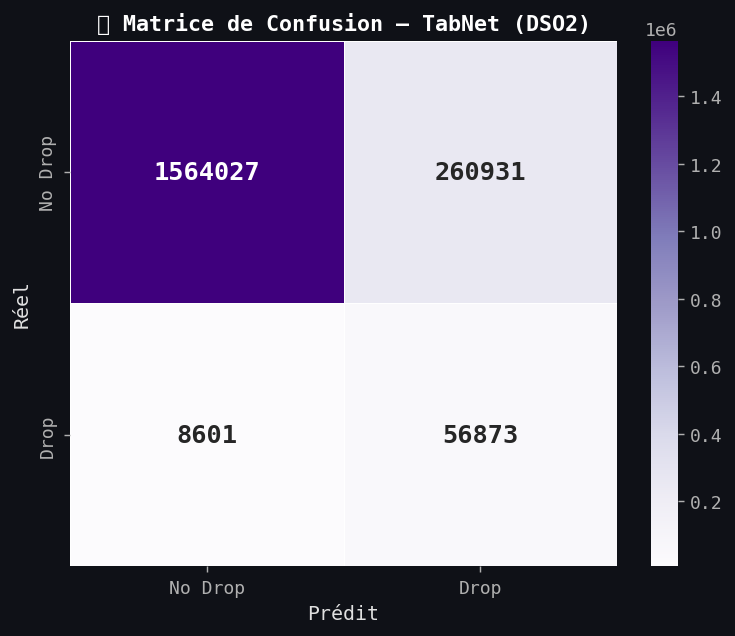

  VN=1,564,027  FP=260,931
  FN=8,601  VP=56,873


In [15]:
# ── Matrice de Confusion — TabNet ────────────────────────────────────────────
cm_tn=confusion_matrix(y_test,y_pred_tn)
fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(cm_tn,annot=True,fmt='d',cmap='Purples',xticklabels=CM_LABELS,yticklabels=CM_LABELS,
    linewidths=0.5,ax=ax,annot_kws={'size':14,'weight':'bold'})
ax.set_xlabel('Prédit',fontsize=11); ax.set_ylabel('Réel',fontsize=11)
ax.set_title('🔢 Matrice de Confusion — TabNet (DSO2)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_tabnet_dso2.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()
print(f'  VN={cm_tn[0,0]:,}  FP={cm_tn[0,1]:,}\n  FN={cm_tn[1,0]:,}  VP={cm_tn[1,1]:,}')

---
## Section 7 — Grille comparative & Dashboard

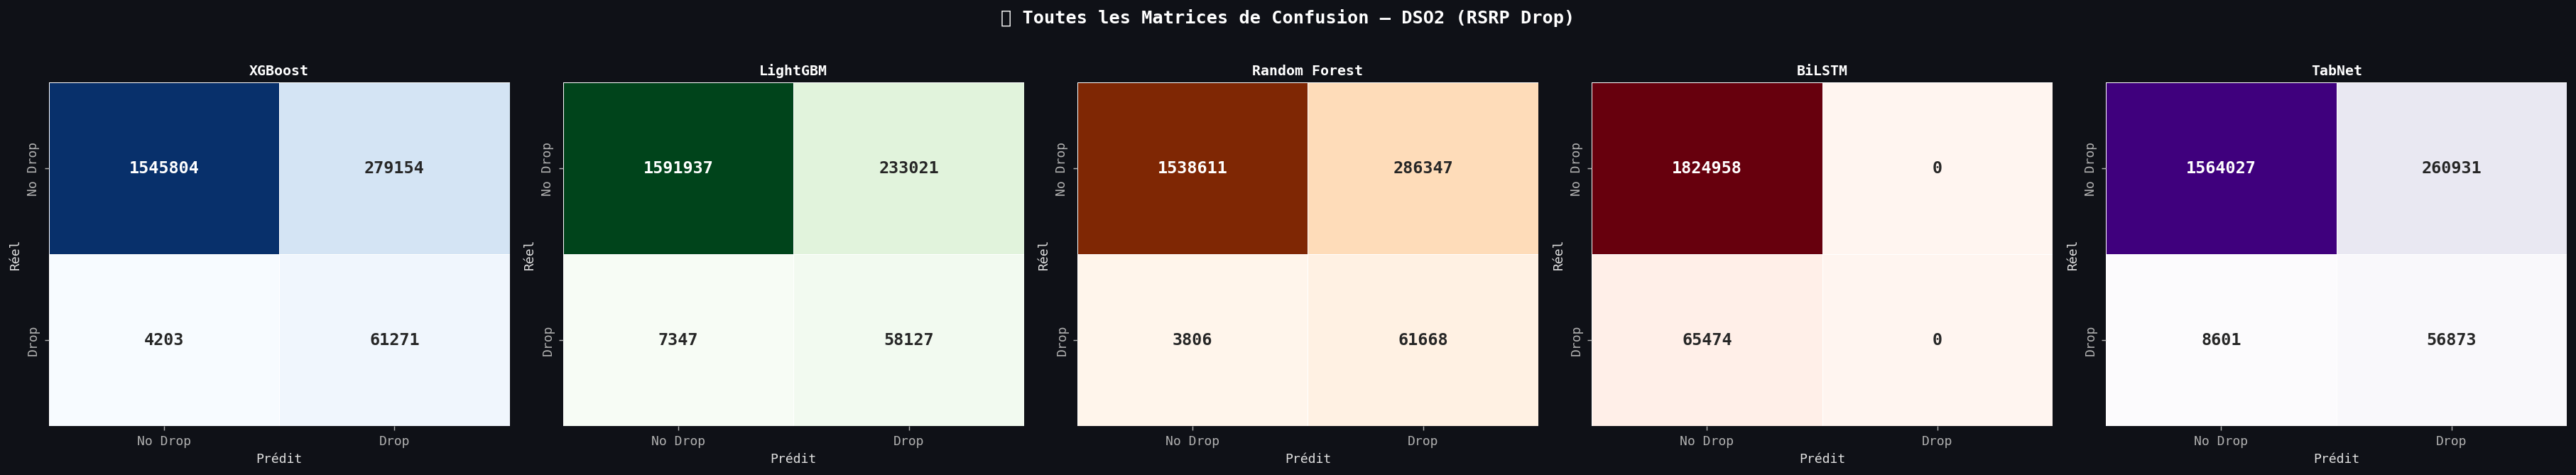

                   f1  precision  recall  auc_roc  auc_pr
model                                                    
XGBoost        0.3019     0.1800  0.9358   0.9521  0.4458
LightGBM       0.3260     0.1996  0.8878   0.9515  0.4488
Random Forest  0.2983     0.1772  0.9419   0.9489  0.4279
BiLSTM         0.0000     0.0000  0.0000   0.5000  0.0346
TabNet         0.2968     0.1790  0.8686   0.9248  0.3065

🏆 Meilleur (F1) : LightGBM → 0.3260


In [16]:
fig,axes=plt.subplots(1,5,figsize=(28,5))
models_cm=[('XGBoost',cm_xgb,'Blues'),('LightGBM',cm_lgbm,'Greens'),
           ('Random Forest',cm_rf,'Oranges'),('BiLSTM',cm_lstm,'Reds'),('TabNet',cm_tn,'Purples')]
for ax,(name,cm,cmap) in zip(axes,models_cm):
    sns.heatmap(cm,annot=True,fmt='d',cmap=cmap,xticklabels=CM_LABELS,yticklabels=CM_LABELS,
        linewidths=0.5,ax=ax,annot_kws={'size':13,'weight':'bold'},cbar=False)
    ax.set_title(name,fontsize=11,fontweight='bold'); ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
plt.suptitle('🔢 Toutes les Matrices de Confusion — DSO2 (RSRP Drop)',fontsize=14,fontweight='bold',color='white',y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_all_dso2.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()

all_metrics=[metrics_xgb,metrics_lgbm,metrics_rf,metrics_lstm,metrics_tn]
df_results=pd.DataFrame(all_metrics).set_index('model')
print(df_results.to_string())
best=df_results['f1'].idxmax()
print(f'\n🏆 Meilleur (F1) : {best} → {df_results.loc[best,"f1"]:.4f}')
with open(os.path.join(MODEL_OUT_DIR,'results_dso2.json'),'w') as f: json.dump(all_metrics,f,indent=2)